In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Colab'da eksik olabilecek kütüphaneleri hızlıca kuralım
!pip install transformers datasets accelerate peft

Mounted at /content/drive


In [ ]:
# Google Colab ortamı kontrol et ve gerekli kütüphaneleri yükle
!pip install -q transformers torch scikit-learn pandas numpy matplotlib seaborn tqdm

import os
import warnings
warnings.filterwarnings('ignore')

# GPU kontrol et
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

PyTorch Version: 2.10.0+cu128
GPU Available: True
GPU Name: Tesla T4
Using device: cuda



In [ ]:
!pip install transformers

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from torch.optim import AdamW
from typing import List, Tuple
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    roc_auc_score, accuracy_score
)
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from tqdm import tqdm
import json

# Görselleştirme ayarları
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

In [ ]:
# CSV dosyasını yükle
# UYARI: Dosya yolunuzu güncelle!
all_data = pd.read_csv('/content/drive/MyDrive/All_Data.csv')

# Veri kontrolü
print("Dataset Bilgisi:")
print(f"Shape: {all_data.shape}")
print(f"\nSütunlar: {all_data.columns.tolist()}")
print(f"\nİlk 3 satır:")
print(all_data.head(3))

Dataset Bilgisi:
Shape: (227551, 2)

Sütunlar: ['Hasta_Yorumu', 'Label']

İlk 3 satır:
                                        Hasta_Yorumu  Label
0  Yaşım 70, cinsiyetim erkek. Size sağlık durumu...      0
1  Hasta Bilgisi: Birey 60 yaşında (erkek). Şikay...      1
2  Hasta Bilgisi: Birey 66 yaşında (erkek). Şikay...      1


VERİ ANALİZİ

Veri Boyutu: 227551 hastanın yorumu

Eksik Değerler:
Hasta_Yorumu    0
Label           0
dtype: int64

Label Dağılımı:
Label
1    135551
0     92000
Name: count, dtype: int64

Label Dağılımı (%):
Label
1    59.569503
0    40.430497
Name: proportion, dtype: float64


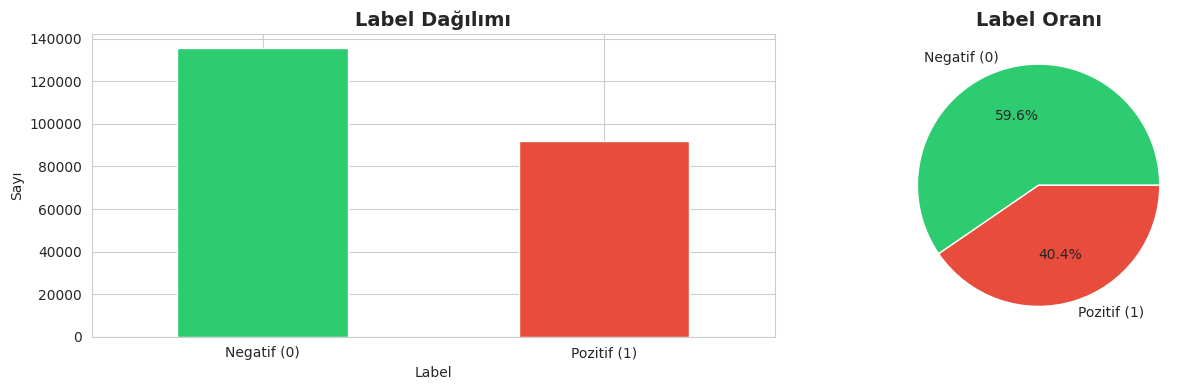


Metin İstatistikleri:
  Min uzunluk: 293
  Max uzunluk: 557
  Ortalama: 413.53
  Medyan: 408.00


In [ ]:
# İstatistiksel özet
print("="*60)
print("VERİ ANALİZİ")
print("="*60)

print(f"\nVeri Boyutu: {len(all_data)} hastanın yorumu\n")

# Missing values kontrol
print("Eksik Değerler:")
print(all_data.isnull().sum())

# Label dağılımı
print("\nLabel Dağılımı:")
label_dist = all_data['Label'].value_counts()
print(label_dist)

# Yüzde
print("\nLabel Dağılımı (%):")
print(all_data['Label'].value_counts(normalize=True) * 100)

# Görselleştir
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar plot
label_dist.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Label Dağılımı', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Sayı')
axes[0].set_xticklabels(['Negatif (0)', 'Pozitif (1)'], rotation=0)

# Pie chart
axes[1].pie(label_dist.values, labels=['Negatif (0)', 'Pozitif (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Label Oranı', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Metin uzunluğu analizi
all_data['text_length'] = all_data['Hasta_Yorumu'].str.len()
all_data['word_count'] = all_data['Hasta_Yorumu'].str.split().str.len()

print("\nMetin İstatistikleri:")
print(f"  Min uzunluk: {all_data['text_length'].min()}")
print(f"  Max uzunluk: {all_data['text_length'].max()}")
print(f"  Ortalama: {all_data['text_length'].mean():.2f}")
print(f"  Medyan: {all_data['text_length'].median():.2f}")

In [ ]:
def temizle_metni(metin: str) -> str:
    """
    Türkçe metni temizle
    - Küçük harfe çevir
    - URL kaldır
    - Email kaldır
    - Özel karakterler kaldır
    - Fazla boşlukları kaldır
    """

    if not isinstance(metin, str):
        return ""

    # 1. Küçük harfe çevir
    metin = metin.lower()

    # 2. URL ve email kaldır
    metin = re.sub(r'http\S+|www\S+|[a-z0-9._%+-]+@[a-z0-9.-]+\.[a-z]{2,}', '', metin)

    # 3. Sayıları kaldır (opsiyonel)
    # metin = re.sub(r'\d+', '', metin)

    # 4. Özel karakterleri kaldır (noktalama işaretleri hariç)
    metin = re.sub(r'[^\w\s\.\,\!\?ç ğ ı ö ş ü]', '', metin)

    # 5. Fazla boşlukları kaldır
    metin = re.sub(r'\s+', ' ', metin).strip()

    return metin

# Temizlemeyi uygula
print("Veri temizleniyor...")
all_data['Hasta_Yorumu_Temiz'] = all_data['Hasta_Yorumu'].apply(temizle_metni)

print("✓ Temizleme tamamlandı")
print("\nÖnce ve Sonra Karşılaştırması:")
print(f"Orijinal: {all_data['Hasta_Yorumu'].iloc[0][:100]}")
print(f"Temiz:    {all_data['Hasta_Yorumu_Temiz'].iloc[0][:100]}")

Veri temizleniyor...
✓ Temizleme tamamlandı

Önce ve Sonra Karşılaştırması:
Orijinal: Yaşım 70, cinsiyetim erkek. Size sağlık durumumu özetlemek istiyorum. Ailemde kanser geçmişi yok. Ke
Temiz:    yaşım 70, cinsiyetim erkek. size sağlık durumumu özetlemek istiyorum. ailemde kanser geçmişi yok. ke


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

✓ Tokenizer yüklendi: dbmdz/bert-base-turkish-cased

Tokenizer Test:
Metin: yaşım 70, cinsiyetim erkek. size sağlık durumumu özetlemek istiyorum. ailemde ka...
Token sayısı: 80
Token örnekleri: [2, 14613, 1027, 5472, 16, 12158, 1995, 3399, 18, 3324]

Token Uzunluk İstatistikleri:
  Max: 110
  Min: 57
  Ortalama: 81.26
  90. Percentil: 86.00


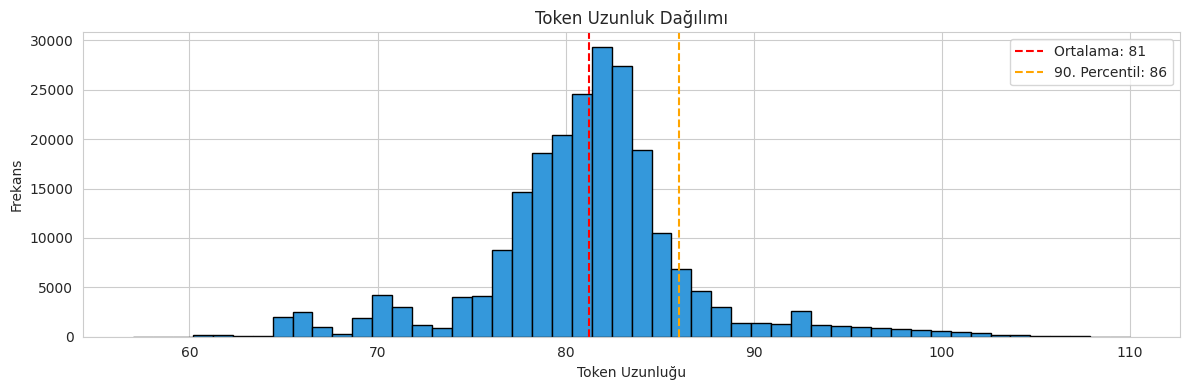


→ Kullanılacak MAX_LEN: 101


In [ ]:
# Turkish BERT tokenizer yükle
model_name = "dbmdz/bert-base-turkish-cased"
tokenizer = BertTokenizer.from_pretrained(model_name)

print(f"✓ Tokenizer yüklendi: {model_name}")

# Tokenizer test et
test_text = all_data['Hasta_Yorumu_Temiz'].iloc[0]
tokens = tokenizer.encode(test_text, add_special_tokens=True)

print(f"\nTokenizer Test:")
print(f"Metin: {test_text[:80]}...")
print(f"Token sayısı: {len(tokens)}")
print(f"Token örnekleri: {tokens[:10]}")

# Token uzunlukları analiz et
token_lengths = []
for text in all_data['Hasta_Yorumu_Temiz']:
    tokens = tokenizer.encode(text, add_special_tokens=True)
    token_lengths.append(len(tokens))

print(f"\nToken Uzunluk İstatistikleri:")
print(f"  Max: {max(token_lengths)}")
print(f"  Min: {min(token_lengths)}")
print(f"  Ortalama: {np.mean(token_lengths):.2f}")
print(f"  90. Percentil: {np.percentile(token_lengths, 90):.2f}")

# Görselleştir
plt.figure(figsize=(12, 4))
plt.hist(token_lengths, bins=50, color='#3498db', edgecolor='black')
plt.axvline(np.mean(token_lengths), color='red', linestyle='--', label=f'Ortalama: {np.mean(token_lengths):.0f}')
plt.axvline(np.percentile(token_lengths, 90), color='orange', linestyle='--', label=f'90. Percentil: {np.percentile(token_lengths, 90):.0f}')
plt.xlabel('Token Uzunluğu')
plt.ylabel('Frekans')
plt.title('Token Uzunluk Dağılımı')
plt.legend()
plt.tight_layout()
plt.show()

# Max token length belirle
MAX_LEN = int(np.percentile(token_lengths, 95)) + 10  # 95. percentil + buffer
print(f"\n→ Kullanılacak MAX_LEN: {MAX_LEN}")

In [ ]:
class KanserDataset(Dataset):
    """
    Kolorektal kanser verisi için custom Dataset sınıfı
    """
    def __init__(self, texts: List[str], labels: List[int],
                 tokenizer, max_length: int = 128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Tokenize et
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Test et
print("Dataset Sınıfı Testi:")
sample_dataset = KanserDataset(
    texts=all_data['Hasta_Yorumu_Temiz'].values[:2],
    labels=all_data['Label'].values[:2],
    tokenizer=tokenizer,
    max_length=MAX_LEN
)

sample = sample_dataset[0]
print(f"Sample input_ids shape: {sample['input_ids'].shape}")
print(f"Sample attention_mask shape: {sample['attention_mask'].shape}")
print(f"Sample label: {sample['label']}")

Dataset Sınıfı Testi:
Sample input_ids shape: torch.Size([101])
Sample attention_mask shape: torch.Size([101])
Sample label: 0


In [ ]:
# Train-validation-test split (70-15-15)
train_text, temp_text, train_label, temp_label = train_test_split(
    all_data['Hasta_Yorumu_Temiz'].values,
    all_data['Label'].values,
    test_size=0.3,
    random_state=42,
    stratify=all_data['Label'].values
)

val_text, test_text, val_label, test_label = train_test_split(
    temp_text, temp_label,
    test_size=0.5,
    random_state=42,
    stratify=temp_label
)

print("Train-Validation-Test Split:")
print(f"Training set: {len(train_text)} ({len(train_text)/len(all_data)*100:.1f}%)")
print(f"Validation set: {len(val_text)} ({len(val_text)/len(all_data)*100:.1f}%)")
print(f"Test set: {len(test_text)} ({len(test_text)/len(all_data)*100:.1f}%)")

# Class dağılımı kontrol et
print("\nTrain Class Dağılımı:")
unique, counts = np.unique(train_label, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} ({c/len(train_label)*100:.1f}%)")

# Dataset oluştur
train_dataset = KanserDataset(train_text, train_label, tokenizer, MAX_LEN)
val_dataset = KanserDataset(val_text, val_label, tokenizer, MAX_LEN)
test_dataset = KanserDataset(test_text, test_label, tokenizer, MAX_LEN)

print("\n✓ Datasets oluşturuldu")

Train-Validation-Test Split:
Training set: 159285 (70.0%)
Validation set: 34133 (15.0%)
Test set: 34133 (15.0%)

Train Class Dağılımı:
  Class 0: 64400 (40.4%)
  Class 1: 94885 (59.6%)

✓ Datasets oluşturuldu


In [ ]:
# Hyperparameters
BATCH_SIZE = 32
SHUFFLE = True

# DataLoaders oluştur
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=SHUFFLE,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("DataLoaders Oluşturuldu:")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Örnek batch
sample_batch = next(iter(train_loader))
print(f"\nÖrnek Batch:")
print(f"  input_ids shape: {sample_batch['input_ids'].shape}")
print(f"  attention_mask shape: {sample_batch['attention_mask'].shape}")
print(f"  labels shape: {sample_batch['label'].shape}")

DataLoaders Oluşturuldu:
Training batches: 4978
Validation batches: 1067
Test batches: 1067

Örnek Batch:
  input_ids shape: torch.Size([32, 101])
  attention_mask shape: torch.Size([32, 101])
  labels shape: torch.Size([32])


In [ ]:
# BERT modeli yükle
model = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,  # Binary classification
    output_attentions=False,
    output_hidden_states=False
)

model.to(device)

print(f"✓ Model yüklendi: {model_name}")
print(f"✓ Device: {device}")
print(f"\nModel Architecture:")
print(model)

# Model parametreleri
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model yüklendi: dbmdz/bert-base-turkish-cased
✓ Device: cuda

Model Architecture:
BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=7

In [ ]:
# ===== HİPERPARAMETRELER =====
EPOCHS = 3  # Bu satır buraya taşındı
PATIENCE = 2  # Early stopping

# ===== OPTIMIZER =====
optimizer = AdamW(model.parameters(), lr=2e-5)

# ===== LEARNING RATE SCHEDULER =====
# Total training steps
total_steps = len(train_loader) * EPOCHS  # Şimdi train_loader tanımlanmış

# Warmup steps
warmup_steps = int(0.1 * total_steps)

# Learning rate scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print("=" * 80)
print("OPTIMIZER & SCHEDULER AYARLANDI")
print("=" * 80)
print(f"✓ Optimizer: AdamW (lr=2e-5)")
print(f"✓ Epochs: {EPOCHS}")
print(f"✓ Total steps: {total_steps}")
print(f"✓ Warmup steps: {warmup_steps}")
print(f"✓ Patience: {PATIENCE}")

OPTIMIZER & SCHEDULER AYARLANDI
✓ Optimizer: AdamW (lr=2e-5)
✓ Epochs: 3
✓ Total steps: 14934
✓ Warmup steps: 1493
✓ Patience: 2


In [ ]:
def train_epoch(model, train_loader, optimizer, scheduler, device):
    """
    Bir epoch boyunca modeli eğit
    """
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(train_loader, desc='Training')

    for batch in progress_bar:
        # Veriyi device'a taşı
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        # İstatistikler
        total_loss += loss.item()

        predictions = torch.argmax(logits, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{correct/total:.4f}'
        })

    avg_loss = total_loss / len(train_loader)
    avg_accuracy = correct / total

    return avg_loss, avg_accuracy

print("✓ Eğitim fonksiyonu tanımlandı")

✓ Eğitim fonksiyonu tanımlandı


In [ ]:
def validate_epoch(model, val_loader, device):
    """
    Validation seti üzerinde modeli değerlendir
    """
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        progress_bar = tqdm(val_loader, desc='Validation')

        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(val_loader)
    avg_accuracy = correct / total

    return avg_loss, avg_accuracy, all_preds, all_labels

print("✓ Validasyon fonksiyonu tanımlandı")

✓ Validasyon fonksiyonu tanımlandı


In [ ]:
# Hyperparameters
EPOCHS = 3
PATIENCE = 2  # Early stopping

# Eğitim geçmişi
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_loss = float('inf')
patience_counter = 0

print("=" * 80)
print("EĞITIM BAŞLANIYOR")
print("=" * 80)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 80)

    # Eğitim
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, device
    )

    # Validasyon
    val_loss, val_acc, _, _ = validate_epoch(model, val_loader, device)

    # Geçmişe ekle
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Sonuçlar
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        # En iyi modeli kaydet
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"→ En iyi model kaydedildi (Val Loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping. Best val loss: {best_val_loss:.4f}")
            break

print("\n" + "=" * 80)
print("EĞITIM TAMAMLANDI")
print("=" * 80)

# En iyi modeli yükle
model.load_state_dict(torch.load('best_model.pth'))

EĞITIM BAŞLANIYOR

Epoch 1/3
--------------------------------------------------------------------------------


Validation: 100%|██████████| 1067/1067 [04:05<00:00,  4.35it/s]


Train Loss: 0.4632 | Train Acc: 0.7395
Val Loss:   0.4469 | Val Acc:   0.7526
→ En iyi model kaydedildi (Val Loss: 0.4469)

Epoch 2/3
--------------------------------------------------------------------------------


Validation: 100%|██████████| 1067/1067 [04:03<00:00,  4.38it/s]


Train Loss: 0.4484 | Train Acc: 0.7516
Val Loss:   0.4440 | Val Acc:   0.7526
→ En iyi model kaydedildi (Val Loss: 0.4440)

Epoch 3/3
--------------------------------------------------------------------------------


Validation: 100%|██████████| 1067/1067 [04:05<00:00,  4.35it/s]


Train Loss: 0.4453 | Train Acc: 0.7527
Val Loss:   0.4434 | Val Acc:   0.7526
→ En iyi model kaydedildi (Val Loss: 0.4434)

EĞITIM TAMAMLANDI


<All keys matched successfully>

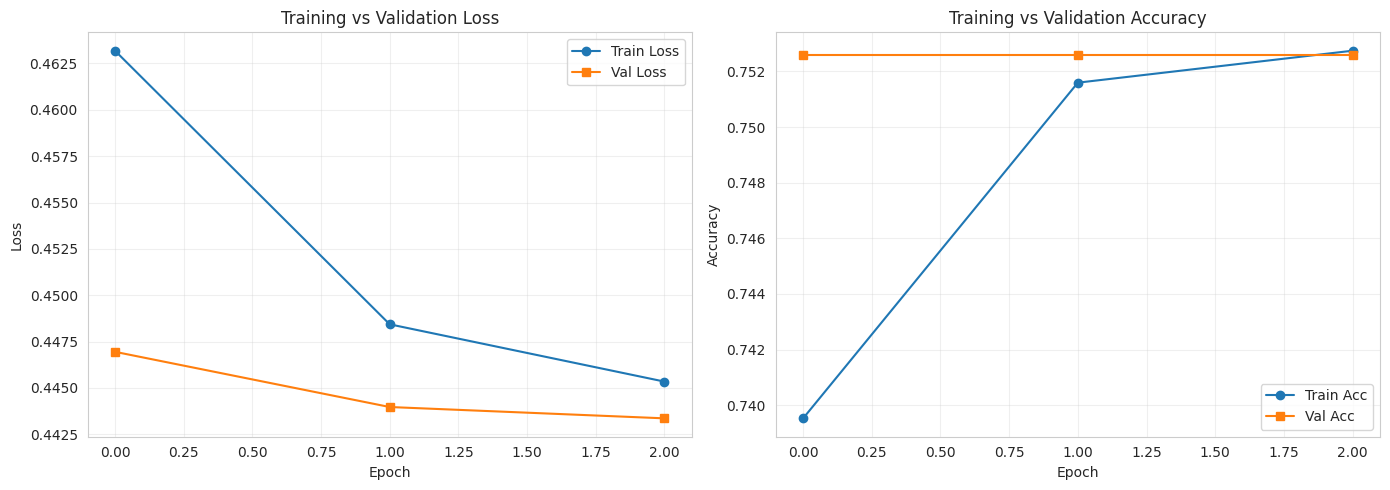

In [ ]:
# Eğitim grafiklerini çiz
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Test seti üzerinde değerlendir
model.eval()
test_preds = []
test_labels = []
test_probs = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Testing'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)

        predictions = torch.argmax(logits, dim=1)

        test_preds.extend(predictions.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())

test_preds = np.array(test_preds)
test_labels = np.array(test_labels)
test_probs = np.array(test_probs)

print("\n" + "=" * 80)
print("TEST SETİ SONUÇLARI")
print("=" * 80)

# Accuracy
accuracy = accuracy_score(test_labels, test_preds)
print(f"\nAccuracy: {accuracy:.4f}")

# Precision, Recall, F1
precision = precision_score(test_labels, test_preds)
recall = recall_score(test_labels, test_preds)
f1 = f1_score(test_labels, test_preds)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Classification Report
print("\nDetaylı Classification Report:")
print(classification_report(test_labels, test_preds,
                          target_names=['Negatif (0)', 'Pozitif (1)']))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
print(f"\nConfusion Matrix:")
print(cm)

Testing: 100%|██████████| 1067/1067 [04:07<00:00,  4.31it/s]


TEST SETİ SONUÇLARI

Accuracy: 0.7557
Precision: 0.7092
Recall: 1.0000
F1-Score: 0.8299

Detaylı Classification Report:
              precision    recall  f1-score   support

 Negatif (0)       1.00      0.40      0.57     13800
 Pozitif (1)       0.71      1.00      0.83     20333

    accuracy                           0.76     34133
   macro avg       0.85      0.70      0.70     34133
weighted avg       0.83      0.76      0.72     34133


Confusion Matrix:
[[ 5463  8337]
 [    0 20333]]


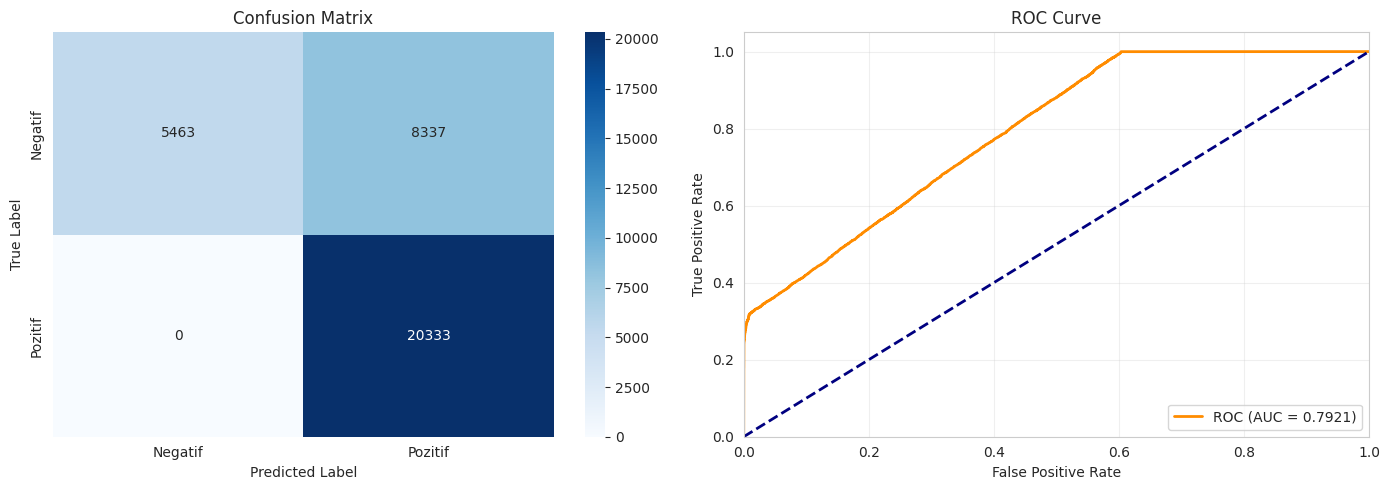

In [ ]:
# Confusion Matrix görselleştir
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negatif', 'Pozitif'],
            yticklabels=['Negatif', 'Pozitif'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(test_labels, test_probs[:, 1])
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def predict_single(text, model, tokenizer, device, max_length=MAX_LEN):
    """
    Tek bir metin için tahmin yap
    """
    # Metni temizle
    text_clean = temizle_metni(text)

    # Tokenize et
    encoding = tokenizer(
        text_clean,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    # Tahmin yap
    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)

    pred_class = torch.argmax(logits, dim=1).item()
    pred_prob = probs[0][pred_class].item()

    return {
        'class': pred_class,
        'class_name': 'Pozitif (Kanser)' if pred_class == 1 else 'Negatif',
        'confidence': pred_prob,
        'probabilities': {
            'negative': probs[0][0].item(),
            'positive': probs[0][1].item()
        }
    }

print("✓ Prediksiyon fonksiyonu tanımlandı")

# Test et
sample_text = "70 yaşında erkek hastayım, son zamanlarda bağırsaklarımda sorun yaşıyorum"
result = predict_single(sample_text, model, tokenizer, device)

print(f"\nÖrnek Tahmin:")
print(f"Metin: {sample_text}")
print(f"Tahmin: {result['class_name']}")
print(f"Güven: {result['confidence']:.4f}")
print(f"Olasılıklar: Negatif={result['probabilities']['negative']:.4f}, Pozitif={result['probabilities']['positive']:.4f}")

✓ Prediksiyon fonksiyonu tanımlandı

Örnek Tahmin:
Metin: 70 yaşında erkek hastayım, son zamanlarda bağırsaklarımda sorun yaşıyorum
Tahmin: Negatif
Güven: 0.6181
Olasılıklar: Negatif=0.6181, Pozitif=0.3819


In [ ]:
# Test metinleri
test_texts = [
    "Ben 65 yaşında bir erkek hastayım. Yaklaşık 3 aydır bağırsaklarımda değişiklik yaşıyorum.",
    "50 yaşında bir kadınım, hiçbir sağlık problemim yok.",
    "Yaşlı bir erkek hastanız, kan kaybı ve kilo kaybı yaşıyorum."
]

print("\n" + "=" * 80)
print("MÜLTİPL TAHMIN SONUÇLARI")
print("=" * 80)

for i, text in enumerate(test_texts, 1):
    result = predict_single(text, model, tokenizer, device)
    print(f"\nTahmin {i}:")
    print(f"  Metin: {text}")
    print(f"  Sonuç: {result['class_name']}")
    print(f"  Güven: {result['confidence']:.4f}")
    print(f"  Negatif: {result['probabilities']['negative']:.4f}")
    print(f"  Pozitif: {result['probabilities']['positive']:.4f}")


MÜLTİPL TAHMIN SONUÇLARI

Tahmin 1:
  Metin: Ben 65 yaşında bir erkek hastayım. Yaklaşık 3 aydır bağırsaklarımda değişiklik yaşıyorum.
  Sonuç: Pozitif (Kanser)
  Güven: 0.6390
  Negatif: 0.3610
  Pozitif: 0.6390

Tahmin 2:
  Metin: 50 yaşında bir kadınım, hiçbir sağlık problemim yok.
  Sonuç: Pozitif (Kanser)
  Güven: 0.5298
  Negatif: 0.4702
  Pozitif: 0.5298

Tahmin 3:
  Metin: Yaşlı bir erkek hastanız, kan kaybı ve kilo kaybı yaşıyorum.
  Sonuç: Pozitif (Kanser)
  Güven: 0.9015
  Negatif: 0.0985
  Pozitif: 0.9015


In [ ]:
## Modeli ve tokenizer'ı kaydet (bunlar config.json'u zaten doğru şekilde oluşturur)
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)

# Kendi ek bilgilerini farklı dosyaya yaz
import json
training_config = {
    'model_name': model_name,
    'max_length': MAX_LEN,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'test_accuracy': float(accuracy),
    'test_f1': float(f1),
    'test_precision': float(precision),
    'test_recall': float(recall)
}

with open(f'{model_save_path}/training_info.json', 'w') as f:
    json.dump(training_config, f, indent=4)

In [ ]:
print("\n" + "=" * 80)
print("FİNAL RAPOR - KOLOREKTAL KANSER KDS SİSTEMİ")
print("=" * 80)

print("\n📊 VERİ İSTATİSTİKLERİ:")
print(f"  Total Veri: {len(all_data)}")
print(f"  Train: {len(train_text)} ({len(train_text)/len(all_data)*100:.1f}%)")
print(f"  Validation: {len(val_text)} ({len(val_text)/len(all_data)*100:.1f}%)")
print(f"  Test: {len(test_text)} ({len(test_text)/len(all_data)*100:.1f}%)")

print("\n🤖 MODEL BİLGİSİ:")
print(f"  Model: {model_name}")
print(f"  Max Length: {MAX_LEN}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Total Parameters: {total_params:,}")

print("\n📈 TEST PERFORMANSI:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1-Score: {f1:.4f}")
print(f"  AUC-ROC: {roc_auc:.4f}")

print("\n💾 KAYIT KONUMU:")
print(f"  {model_save_path}")

print("\n" + "=" * 80)


FİNAL RAPOR - KOLOREKTAL KANSER KDS SİSTEMİ

📊 VERİ İSTATİSTİKLERİ:
  Total Veri: 227551
  Train: 159285 (70.0%)
  Validation: 34133 (15.0%)
  Test: 34133 (15.0%)

🤖 MODEL BİLGİSİ:
  Model: dbmdz/bert-base-turkish-cased
  Max Length: 101
  Batch Size: 32
  Epochs: 3
  Total Parameters: 110,618,882

📈 TEST PERFORMANSI:
  Accuracy: 0.7557
  Precision: 0.7092
  Recall: 1.0000
  F1-Score: 0.8299
  AUC-ROC: 0.7921

💾 KAYIT KONUMU:
  /content/drive/MyDrive/colorectal_cancer_model



In [ ]:
# Detaylı istatistiksel analiz
from sklearn.metrics import confusion_matrix

# cm'i hesaplamak için (eğer yoksa)
# cm = confusion_matrix(test_labels, predictions)   # test_labels gerçek, predictions tahmin

print("\n" + "=" * 80)
print("İSTATİSTİKSEL METRIKLER")
print("=" * 80)

tn, fp, fn, tp = cm.ravel()   # Bu satırın çalışması için cm'in tanımlı olması gerek

print(f"\nConfusion Matrix Elemanları:")
print(f"  True Negative (TN): {tn}")
print(f"  False Positive (FP): {fp}")
print(f"  False Negative (FN): {fn}")
print(f"  True Positive (TP): {tp}")

# ... gerisi aynı


İSTATİSTİKSEL METRIKLER

Confusion Matrix Elemanları:
  True Negative (TN): 5463
  False Positive (FP): 8337
  False Negative (FN): 0
  True Positive (TP): 20333
